In [1]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import yaml

from data.patching import build_patch_registry, assign_hits_to_patches_barrel

In [2]:
detector_type = "HCAL"
data_dir = pickle.load(open("/pscratch/sd/r/rmastand/data_dir.pkl", "rb"))


with open("../configs/detector_patching_params.yaml", "r") as ifile:
    detector_patching_params = yaml.safe_load(ifile)[detector_type]
offsets = {}
for i in range(len(detector_patching_params["barrel_configs"]["cells_per_wedge"])):
    offsets[i] = int((detector_patching_params["barrel_configs"]["cells_per_wedge"][i] - detector_patching_params["barrel_configs"]["cells_per_wedge"][0]) / 2)

detector_patching_params["barrel_configs"]["offsets"] = offsets 
    
print(detector_patching_params)

{'cell_size': 30.0, 'layer_width': 51.0, 'endcap_configs': {'n_bins_x': 101, 'x_start_midpoint': 362.5, 'x_stop_midpoint': 3362.5, 'n_bins_y': 45, 'y_start_midpoint': -660.0, 'y_stop_midpoint': 660.0, 'n_bins_z': 36, 'z_start_midpoint': 3647.5, 'z_stop_midpoint': 5432.5}, 'barrel_configs': {'n_bins_x': 36, 'x_start_midpoint': 1647.5, 'x_stop_midpoint': 3432.5, 'n_bins_y': 45, 'y_start_midpoint': -660.0, 'y_stop_midpoint': 660.0, 'n_bins_z': 231, 'z_start_midpoint': -3450.0, 'z_stop_midpoint': 3450.0, 'cells_per_wedge': {0: 23, 1: 23, 2: 23, 3: 25, 4: 25, 5: 25, 6: 27, 7: 27, 8: 27, 9: 29, 10: 29, 11: 29, 12: 31, 13: 31, 14: 31, 15: 33, 16: 33, 17: 33, 18: 35, 19: 35, 20: 35, 21: 37, 22: 37, 23: 37, 24: 39, 25: 39, 26: 39, 27: 41, 28: 41, 29: 41, 30: 43, 31: 43, 32: 43, 33: 45, 34: 45, 35: 45}, 'cells_per_patch_z': 11, 'groups': [0, 18, 36], 'offsets': {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 3, 10: 3, 11: 3, 12: 4, 13: 4, 14: 4, 15: 5, 16: 5, 17: 5, 18: 6, 19: 6, 20: 6

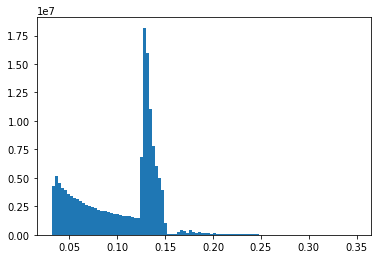

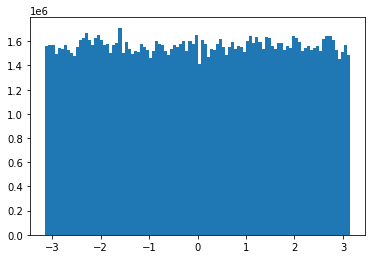

In [6]:
# for key in data_dir.keys():
#     plt.figure()
#     plt.hist(data_dir[key], bins = 100, histtype = "step", density = True)
#     plt.xlabel(key)
#     plt.ylabel("density")
#     plt.show()


plt.figure()
plt.hist(data_dir["r"] / 1e4, bins = 100)
plt.show()

plt.figure()
plt.hist(np.arctan2(data_dir["y"], data_dir["x"]), bins = 100)
plt.show()

In [7]:
ECAL_layers = [9, 10, 11]
labels = ["ECAL endcap", "ECAL barrel", "ECAL endcap"]
HCAL_layers = [12, 13, 14]
labels = ["HCAL endcap", "HCAL barrel", "HCAL endcap"]


In [8]:
import numpy as np
from collections import defaultdict
from typing import Dict, List, Tuple
import math

"""
detector_vit_patching.py  (v5)

Scheme
------
  r   : layers grouped into rings via `groups`.
        Cell tensor per patch is a list of n_layers_in_ring 2-D arrays,
        each shape (phi_size_for_that_layer, cells_per_patch_z).
        phi_size varies by layer (Bresenham split of that layer's cpw).
  phi : 64 patches = patches_per_wedge (4) × num_wedges (16), wedge-aligned.
        Per-layer Bresenham split: patch i gets
            base + (1 if i < remainder else 0)  cells,
            base = cells_per_wedge[layer] // patches_per_wedge
            remainder = cells_per_wedge[layer] % patches_per_wedge
        Patch 0 always gets the larger slice, consistently across layers.
  z   : driven by cells_per_patch_z.

Total patches = n_rings × n_phi_patches × n_z_patches.
"""

_PATCHES_PER_WEDGE = 4
_NUM_WEDGES        = 16
_N_PHI_PATCHES     = _PATCHES_PER_WEDGE * _NUM_WEDGES   # 64


# --------------------------------------------------------------------------- #
# Phi geometry helpers (per-layer, as in v3)
# --------------------------------------------------------------------------- #

def _phi_patch_sizes_for_cpw(
    cpw: int,
    patches_per_wedge: int = _PATCHES_PER_WEDGE,
) -> List[int]:
    """
    Example: cpw=23, patches=4  →  [6, 6, 6, 5]
             cpw=25, patches=4  →  [7, 6, 6, 6]
             cpw=45, patches=4  →  [12, 11, 11, 11]
    """
    base      = cpw // patches_per_wedge
    remainder = cpw %  patches_per_wedge
    return [base + (1 if i < remainder else 0) for i in range(patches_per_wedge)]


def _phi_patch_starts_for_cpw(
    cpw: int,
    patches_per_wedge: int = _PATCHES_PER_WEDGE,
) -> List[int]:
    """Starting phi-cell offset within a wedge for each within-wedge patch."""
    sizes  = _phi_patch_sizes_for_cpw(cpw, patches_per_wedge)
    starts = [0] * patches_per_wedge
    for i in range(1, patches_per_wedge):
        starts[i] = starts[i - 1] + sizes[i - 1]
    return starts

In [9]:



# --------------------------------------------------------------------------- #
# Registry
# --------------------------------------------------------------------------- #

def build_patch_registry(
    detector_patching_params: Dict,
    num_wedges:        int = _NUM_WEDGES,
    patches_per_wedge: int = _PATCHES_PER_WEDGE,
) -> Tuple[dict, dict, int]:
    """
    Build the complete patch registry for a barrel sub-detector.

    Returns
    -------
    registry          : dict with full patch metadata
    unique_patch_sizes: dict keyed by (ring_idx, within_wedge_idx) ->
                        total number of cells in that patch shape
    total_patches     : int
    """
    cfg         = detector_patching_params["barrel_configs"]
    cell_size   = detector_patching_params["cell_size"]
    layer_width = detector_patching_params["layer_width"]

    cells_per_wedge   = cfg["cells_per_wedge"]
    cells_per_patch_z = cfg["cells_per_patch_z"]
    num_cells_z       = cfg["n_bins_z"]
    n_layers_total    = cfg["n_bins_x"]
    groups            = cfg["groups"]

    r_start = cfg["x_start_midpoint"] - layer_width / 2
    r_stop  = cfg["x_stop_midpoint"]  + layer_width / 2
    z_start = cfg["z_start_midpoint"] - cell_size   / 2
    z_stop  = cfg["z_stop_midpoint"]  + cell_size   / 2

    assert num_cells_z % cells_per_patch_z == 0, \
        "n_bins_z must be divisible by cells_per_patch_z"

    n_z_patches   = num_cells_z // cells_per_patch_z
    n_phi_patches = patches_per_wedge * num_wedges
    n_rings       = len(groups) - 1

    # ------------------------------------------------------------------ #
    # Ring <-> layer mappings
    # ------------------------------------------------------------------ #
    ring_to_layers: Dict[int, Tuple[int, int]] = {}
    layer_to_ring:  Dict[int, int]             = {}
    for ring_idx, (g_start, g_stop) in enumerate(zip(groups[:-1], groups[1:])):
        ring_to_layers[ring_idx] = (g_start, g_stop - 1)
        for l in range(g_start, g_stop):
            layer_to_ring[l] = ring_idx

    # ------------------------------------------------------------------ #
    # Per-layer phi patch geometry
    # ------------------------------------------------------------------ #
    layer_phi_sizes:  Dict[int, List[int]] = {
        l: _phi_patch_sizes_for_cpw(cells_per_wedge[l], patches_per_wedge)
        for l in range(n_layers_total)
    }
    layer_phi_starts: Dict[int, List[int]] = {
        l: _phi_patch_starts_for_cpw(cells_per_wedge[l], patches_per_wedge)
        for l in range(n_layers_total)
    }

    # ------------------------------------------------------------------ #
    # Continuous centre coordinates
    # ------------------------------------------------------------------ #
    r_edges   = np.linspace(r_start, r_stop, n_layers_total + 1)
    r_centers = (r_edges[:-1] + r_edges[1:]) / 2

    def _ring_r_center(ring_idx: int) -> float:
        l_start, l_stop = ring_to_layers[ring_idx]
        return float(np.mean(r_centers[l_start:l_stop + 1]))

    z_edges         = np.linspace(z_start, z_stop, num_cells_z + 1)
    z_cell_centers  = (z_edges[:-1] + z_edges[1:]) / 2
    z_patch_centers = np.array([
        np.mean(z_cell_centers[j * cells_per_patch_z:(j + 1) * cells_per_patch_z])
        for j in range(n_z_patches)
    ])

    phi_patch_centers = np.array([
        2 * np.pi * (phi_idx + 0.5) / n_phi_patches
        for phi_idx in range(n_phi_patches)
    ])

    # ------------------------------------------------------------------ #
    # Build registry
    # ------------------------------------------------------------------ #
    registry = {
        "patches":            [],
        "index":              {},   # (ring_idx, phi_idx, z_idx) -> patch_id
        "n_rings":            n_rings,
        "n_phi_patches":      n_phi_patches,
        "n_z_patches":        n_z_patches,
        "cells_per_patch_z":  cells_per_patch_z,
        "patches_per_wedge":  patches_per_wedge,
        "num_wedges":         num_wedges,
        "ring_to_layers":     ring_to_layers,
        "layer_to_ring":      layer_to_ring,
        "layer_phi_sizes":    layer_phi_sizes,
        "layer_phi_starts":   layer_phi_starts,
    }

    patch_id = 0
    for ring_idx in range(n_rings):
        l_start, l_stop  = ring_to_layers[ring_idx]
        n_layers_in_ring = l_stop - l_start + 1
        rc               = _ring_r_center(ring_idx)

        for phi_idx in range(n_phi_patches):
            wedge_idx        = phi_idx // patches_per_wedge
            within_wedge_idx = phi_idx %  patches_per_wedge

            for z_idx in range(n_z_patches):
                info = {
                    "patch_id":          patch_id,
                    "ring_idx":          ring_idx,
                    "phi_idx":           phi_idx,
                    "z_idx":             z_idx,
                    "wedge_idx":         wedge_idx,
                    "within_wedge_idx":  within_wedge_idx,
                    "layer_start":       l_start,
                    "layer_stop":        l_stop,
                    "n_layers_in_ring":  n_layers_in_ring,
                    "r_center":          rc,
                    "phi_center":        float(phi_patch_centers[phi_idx]),
                    "z_center":          float(z_patch_centers[z_idx]),
                    "z_cell_start":      z_idx * cells_per_patch_z,
                    "z_cell_stop":       (z_idx + 1) * cells_per_patch_z - 1,
                }
                registry["patches"].append(info)
                registry["index"][(ring_idx, phi_idx, z_idx)] = patch_id
                patch_id += 1

    # ------------------------------------------------------------------ #
    # Unique patch sizes keyed by (ring_idx, within_wedge_idx)
    # ------------------------------------------------------------------ #
    unique_patch_sizes: Dict[Tuple[int, int], int] = {}
    for ring_idx in range(n_rings):
        l_start, l_stop  = ring_to_layers[ring_idx]
        n_layers_in_ring = l_stop - l_start + 1
        for ww in range(patches_per_wedge):
            total_cells = sum(
                layer_phi_sizes[l][ww] for l in range(l_start, l_stop + 1)
            ) * cells_per_patch_z
            unique_patch_sizes[(ring_idx, ww)] = total_cells

    # ------------------------------------------------------------------ #
    # Summary
    # ------------------------------------------------------------------ #
    print(f"[Registry] {patch_id} total patches")
    print(f"           {n_rings} rings × {n_phi_patches} phi × {n_z_patches} z")
    print(f"           cells_per_patch_z = {cells_per_patch_z}")
    print(f"           sample phi patch sizes (within-wedge) per ring:")
    for r in range(n_rings):
        l_start, l_stop = ring_to_layers[r]
        sample_layer    = l_start
        print(f"             ring {r:2d} "
              f"(layers {l_start:2d}–{l_stop:2d}, "
              f"cpw[{sample_layer}]={cells_per_wedge[sample_layer]:3d}): "
              f"phi sizes (first layer) = {layer_phi_sizes[sample_layer]}")

    return registry, unique_patch_sizes, patch_id



In [11]:

registry, unique_patch_sizes, _ = build_patch_registry(detector_patching_params)

[Registry] 2688 total patches
           2 rings × 64 phi × 21 z
           cells_per_patch_z = 11
           sample phi patch sizes (within-wedge) per ring:
             ring  0 (layers  0–17, cpw[0]= 23): phi sizes (first layer) = [6, 6, 6, 5]
             ring  1 (layers 18–35, cpw[18]= 35): phi sizes (first layer) = [9, 9, 9, 8]


In [17]:
print(unique_patch_sizes)

{(0, 0): 1485, (0, 1): 1386, (0, 2): 1386, (0, 3): 1287, (1, 0): 2079, (1, 1): 1980, (1, 2): 1980, (1, 3): 1881}


dict_keys(['patches', 'index', 'n_rings', 'n_phi_patches', 'n_z_patches', 'cells_per_patch_z', 'patches_per_wedge', 'num_wedges', 'ring_to_layers', 'layer_to_ring', 'layer_phi_sizes', 'layer_phi_starts'])
64


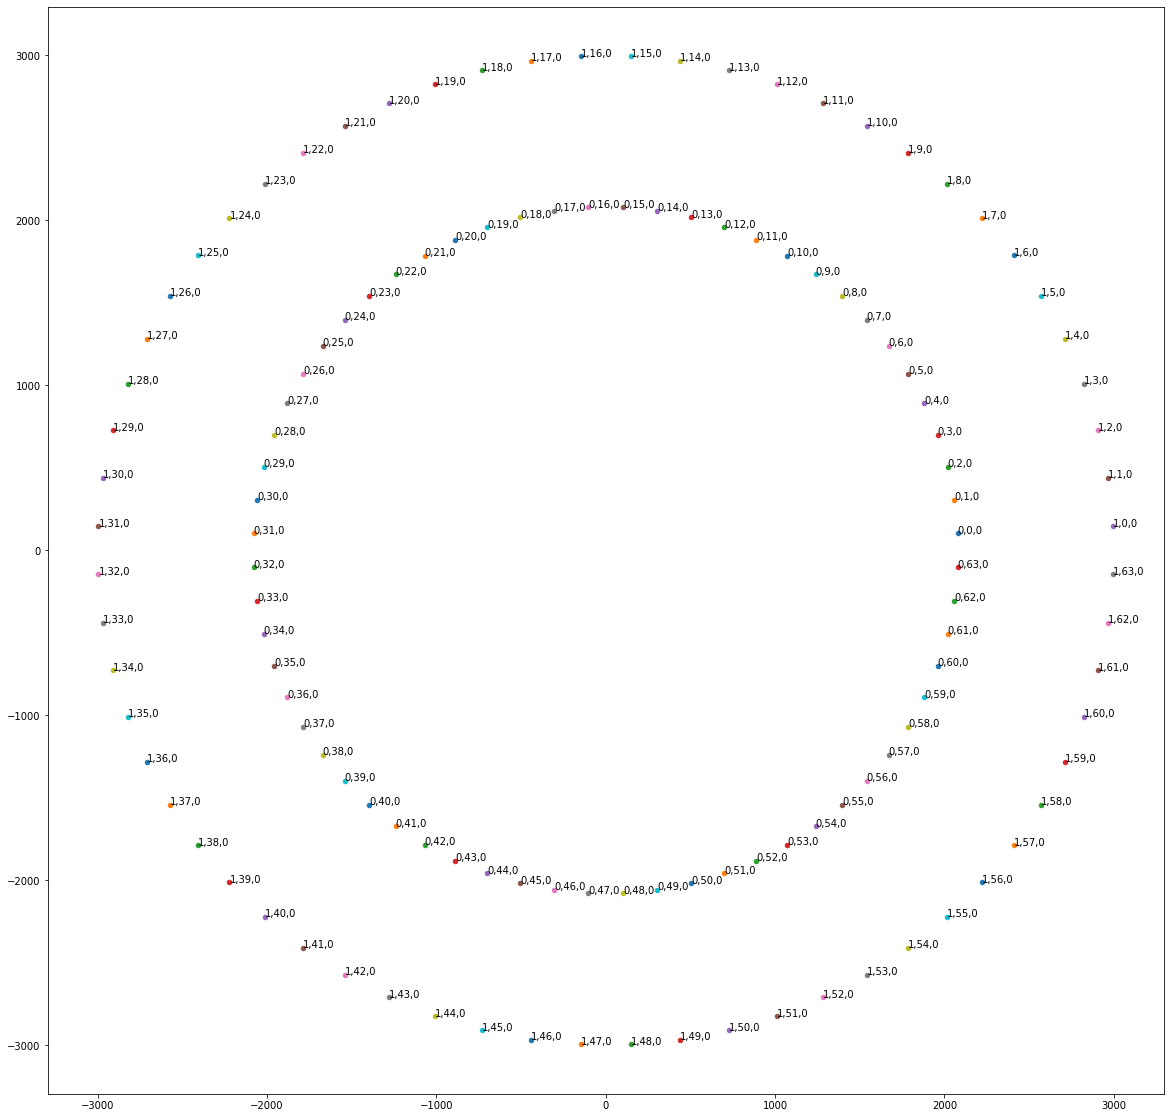

In [14]:


print(registry.keys())

print(registry["n_phi_patches"])
plt.figure(figsize = (20, 20))

for i in range(len(registry["patches"])):


    if registry["patches"][i]["z_center"] == (-3300):
        

        global_id = registry["patches"][i]["patch_id"]
        local_id = str(registry["patches"][i]["ring_idx"])+","+str(registry["patches"][i]["phi_idx"])+","+str(registry["patches"][i]["z_idx"])

        plt.scatter(registry["patches"][i]["r_center"]*np.cos(registry["patches"][i]["phi_center"]), registry["patches"][i]["r_center"]*np.sin(registry["patches"][i]["phi_center"]), s = 20)
        plt.text(registry["patches"][i]["r_center"]*np.cos(registry["patches"][i]["phi_center"]), registry["patches"][i]["r_center"]*np.sin(registry["patches"][i]["phi_center"]), local_id)
plt.show()

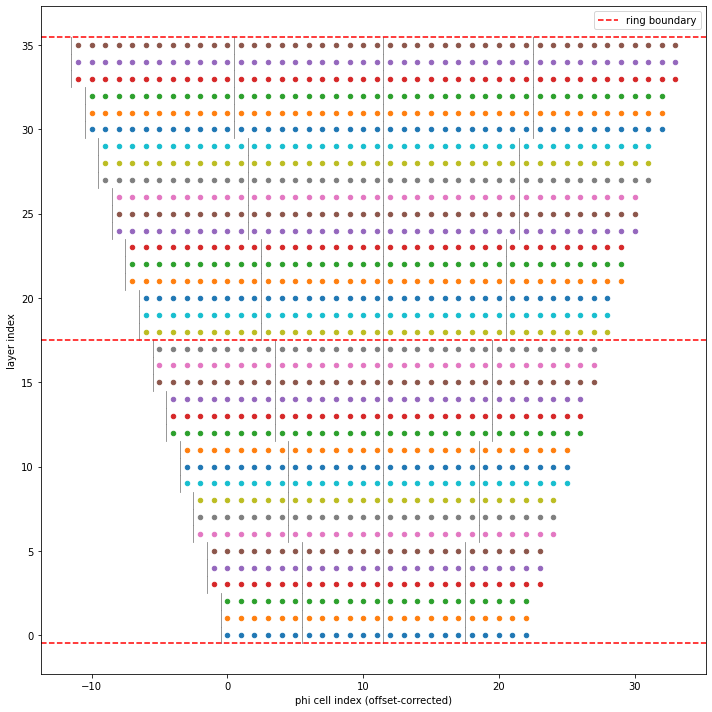

In [16]:
 fig, ax = plt.subplots(figsize=(10, 10))

for layer_i in registry["layer_phi_sizes"].keys():
    cpw     = detector_patching_params["barrel_configs"]["cells_per_wedge"][layer_i]
    offset  = offsets[layer_i]

    x_positions = np.array(range(cpw)) - offset
    y_positions = [layer_i] * cpw
    ax.scatter(x_positions, y_positions, s=20)

    # vertical lines: phi patch boundaries for this layer
    for b in registry["layer_phi_starts"][layer_i]:
        x = b - offset - 0.5
        ax.plot([x, x], [layer_i - 0.5, layer_i + 0.5], color="gray", lw=0.8)

# horizontal lines: ring (group) boundaries
groups = detector_patching_params["barrel_configs"]["groups"]
for g in groups:
    ax.axhline(g - 0.5, color="red", lw=1.5, linestyle="--", label="ring boundary" if g == groups[0] else None)

ax.set_xlabel("phi cell index (offset-corrected)")
ax.set_ylabel("layer index")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
dd = 13


# Example: 36 cells for detector hits
x = np.array(data_dir["x"][data_dir["detector"] == dd])
y = np.array(data_dir["y"][data_dir["detector"] == dd])
z = np.array(data_dir["z"][data_dir["detector"] == dd])
energy = np.array(data_dir["total_energy"][data_dir["detector"] == dd])


results = assign_hits_to_patches_barrel(
    x,
    y,
    z,
    energy,
    registry,
    detector_patching_params,
) 









In [ ]:
print(results)

In [ ]:
print(results[0])

In [ ]:
# this gives the number of unique embedding vectors we need


print(unique_patch_sizes)

In [ ]:
966+840+756+5145+336+336